# 似然与最大似然估计

## Goal
固定观察到的数据，在明确的参数空间内选择使联合质量或密度最大的模型参数。先手算Bernoulli八次三成功与Gaussian(0,1,2,5)，再用稳定log计算、导数、数值搜索和重复采样核验。完整推导在lecture.pdf，独立操作步骤在lab.pdf，18题详解在answers.pdf。

默认实际结果：Bernoulli MLE为3/8；Gaussian均值2、SSE14、方差MLE3.5。n=4的4000批Gaussian模拟中方差MLE均值约2.644831，无偏版本约3.526442，对应理论2.625与3.5。所有数据合成，有限模拟不是真实任务性能。

## Setup
从本单元目录启动。首格检查两份CSV与JSON保持默认设置，避免修改数据却沿用旧手算与图题；变化实验请另存文件，用脚本参数运行并重算理论。核心代码仅用NumPy，图像由Matplotlib内存生成，Notebook保留实际PNG。

In [1]:
import sys, math, io
from fractions import Fraction
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,"axes.spines.right":False,"figure.facecolor":"white"})
def show(fig):
    fig.tight_layout(pad=1.5)
    buf=io.BytesIO(); fig.savefig(buf,format="png",dpi=140,bbox_inches="tight")
    plt.close(fig); display(Image(data=buf.getvalue()))
b=e.load_csv(e.ROOT/'data/bernoulli.csv',binary=True)
x=e.load_csv(e.ROOT/'data/gaussian.csv')
spec=e.load_spec()
e.require(b.tolist()==[1,0,0,1,0,1,0,0],"Notebook requires baseline Bernoulli CSV")
e.require(x.tolist()==[0,1,2,5],"Notebook requires baseline Gaussian CSV")
e.require(spec=={"kind":"synthetic_mle_repeated_sampling","seed":23023,"repetitions":4000,"sizes":[4,16,64],"p":.375,"mu":2.,"variance":3.5},"Use script --spec for changed simulation settings")
print({"Python":sys.version.split()[0],"NumPy":np.__version__,"Matplotlib":matplotlib.__version__,"BitGenerator":"PCG64"})
print("Observed sequence:",b.tolist(),"Gaussian observations:",x.tolist())
print(spec)

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8', 'BitGenerator': 'PCG64'}
Observed sequence: [1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0] Gaussian observations: [0.0, 1.0, 2.0, 5.0]
{'kind': 'synthetic_mle_repeated_sampling', 'seed': 23023, 'repetitions': 4000, 'sizes': [4, 16, 64], 'p': 0.375, 'mu': 2.0, 'variance': 3.5}


### Key Assumptions
每份数据分别假设独立同分布；Bernoulli参数空间[0,1]、支持集{0,1}；Gaussian均值为实数、方差v>0。数值实现另有保守范围，超范围明确拒绝，不自动裁剪。似然是固定数据后关于参数的函数，不是参数的概率分布；连续密度可以超过1。

## Steps
### 1. 先精确手算三点，再看曲线
Fraction只用于独立参考算术；不要用网格最大位置替代解析估计。

p= 1/4 L= 243/65536 decimal= 0.0037078857421875 log L= -5.5972934456185754
p= 3/8 L= 84375/16777216 decimal= 0.005029141902923584 log L= -5.292505905263857
p= 1/2 L= 1/256 decimal= 0.00390625 log L= -5.545177444479562
Closed-form: {'n': 8, 'successes': 3, 'p_mle': 0.375, 'location': 'interior'}


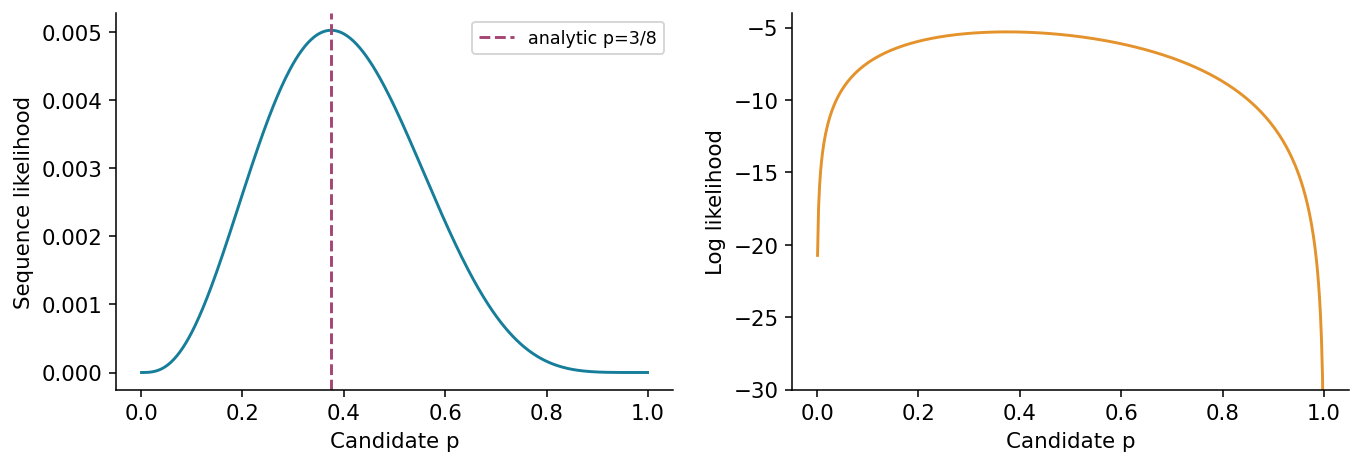

In [2]:
for p in [Fraction(1,4),Fraction(3,8),Fraction(1,2)]:
    exact=p**3*(1-p)**5
    print("p=",str(p),"L=",str(exact),"decimal=",float(exact),"log L=",e.bernoulli_loglik(b,float(p)))
print("Closed-form:",e.bernoulli_mle(b))
ps=np.linspace(.001,.999,500)
ll=np.array([e.bernoulli_loglik(b,float(p)) for p in ps])
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(ps,np.exp(ll),color="#167d9a")
axes[0].axvline(3/8,color="#a54572",ls="--",label="analytic p=3/8")
axes[0].set(xlabel="Candidate p",ylabel="Sequence likelihood")
axes[0].legend(fontsize=9)
axes[1].plot(ps,ll,color="#e4932c")
axes[1].set(xlabel="Candidate p",ylabel="Log likelihood",ylim=(-30,-4))
show(fig)

### 2. 观察规则改成计数，常数是否真与参数无关？
差值应为log56。这个验证没有把似然改成后验概率，也没有比较不同样本量的原始峰高。

In [3]:
for p in [.1,.25,.375,.5,.9]:
    difference=e.bernoulli_loglik(b,p,count_observation=True)-e.bernoulli_loglik(b,p)
    e.require(math.isclose(difference,math.log(56),rel_tol=1e-12),"count/sequence mismatch")
    print(p,"log-count minus log-sequence =",difference)
print("Likelihood ratio p=3/8 versus p=1/2:",float(Fraction(84375,65536)))

0.1 log-count minus log-sequence = 4.02535169073515
0.25 log-count minus log-sequence = 4.02535169073515
0.375 log-count minus log-sequence = 4.02535169073515
0.5 log-count minus log-sequence = 4.02535169073515
0.9 log-count minus log-sequence = 4.02535169073515
Likelihood ratio p=3/8 versus p=1/2: 1.2874603271484375


### 3. 导数与数值搜索分开检查
解析导数指明曲线形状，中心差分只在温和参数和多个步长上交叉核验。二分导数必须先处理全零、全一边界。

In [4]:
print("At MLE, score and curvature:",e.bernoulli_derivatives(b,.375))
p=.3; score=e.bernoulli_derivatives(b,p)[0]
for h in [1e-2,1e-3,1e-4,1e-5]:
    finite_difference=(e.bernoulli_loglik(b,p+h)-e.bernoulli_loglik(b,p-h))/(2*h)
    print("h",h,"difference",finite_difference,"analytic",score,"absolute error",abs(finite_difference-score))
print("Bisection:",e.bisect_bernoulli(b))
print("All-zero:",e.bisect_bernoulli([0]*8))
print("All-one:",e.bisect_bernoulli([1]*8))

At MLE, score and curvature: (0.0, -34.13333333333333)
h 0.01 difference 2.8603630637868527 analytic 2.8571428571428568 absolute error 0.0032202066439959154
h 0.001 difference 2.857175035334336 analytic 2.8571428571428568 absolute error 3.2178191479381724e-05
h 0.0001 difference 2.8571431789226054 analytic 2.8571428571428568 absolute error 3.217797486243512e-07
h 1e-05 difference 2.8571428603019196 analytic 2.8571428571428568 absolute error 3.159062789137579e-09
Bisection: {'p': 0.375, 'bracket': [0.375, 0.375], 'iterations': 3, 'converged': True}
All-zero: {'p': 0.0, 'bracket': [0.0, 0.0], 'iterations': 0, 'converged': True}
All-one: {'p': 1.0, 'bracket': [1.0, 1.0], 'iterations': 0, 'converged': True}


### 4. 边界最大值与logit上确界
相对似然分别除以自身最大值，仅用于比较曲线形状。全零数据在闭区间有p=0的MLE，在有限实数logit空间没有MLE。

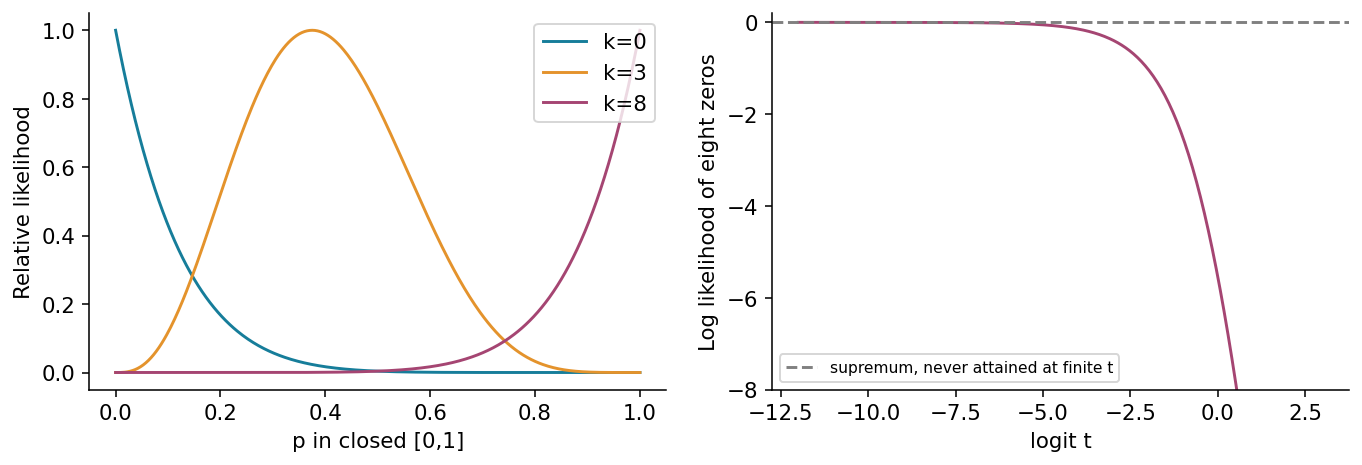

All-zero at p=0: 0.0
Observed one at p=0: -inf
Finite main-sample logit: -0.5108256237659907
P(eight zeros | true p=1/4): 0.1001129150390625


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10,3.6)); grid=np.linspace(0,1,401)
for k,color in [(0,"#167d9a"),(3,"#e4932c"),(8,"#a54572")]:
    y=np.array([math.exp(e.bernoulli_loglik([1]*k+[0]*(8-k),float(p))) for p in grid])
    axes[0].plot(grid,y/y.max(),label=f"k={k}",color=color)
axes[0].set(xlabel="p in closed [0,1]",ylabel="Relative likelihood");axes[0].legend()
t=np.linspace(-12,3,400)
axes[1].plot(t,-8*np.logaddexp(0,t),color="#a54572")
axes[1].axhline(0,color="gray",ls="--",label="supremum, never attained at finite t")
axes[1].set(xlabel="logit t",ylabel="Log likelihood of eight zeros",ylim=(-8,.2))
axes[1].legend(fontsize=8);show(fig)
print("All-zero at p=0:",e.bernoulli_loglik([0]*8,0))
print("Observed one at p=0:",e.bernoulli_loglik([0,1],0))
print("Finite main-sample logit:",math.log(3/5))
print("P(eight zeros | true p=1/4):",float(Fraction(3,4)**8))

### 5. Gaussian手算与两维目标
注意variance是方差；SSE14来自四个中心化离差的平方。等高线只是辅助核验，全局唯一性来自正文的平方和分解和剖面导数。

{'n': 4, 'mean': 2.0, 'sse': 14.0, 'variance_mle': 3.5, 'variance_unbiased': 4.666666666666667, 'status': 'finite_unique_mle'}
Residuals: [-2. -1.  0.  3.] squares: [4. 1. 0. 9.]
Derivatives at fitted pair: (0.0, 0.0)
np.var ddof=0 / ddof=1: 3.5 4.666666666666667


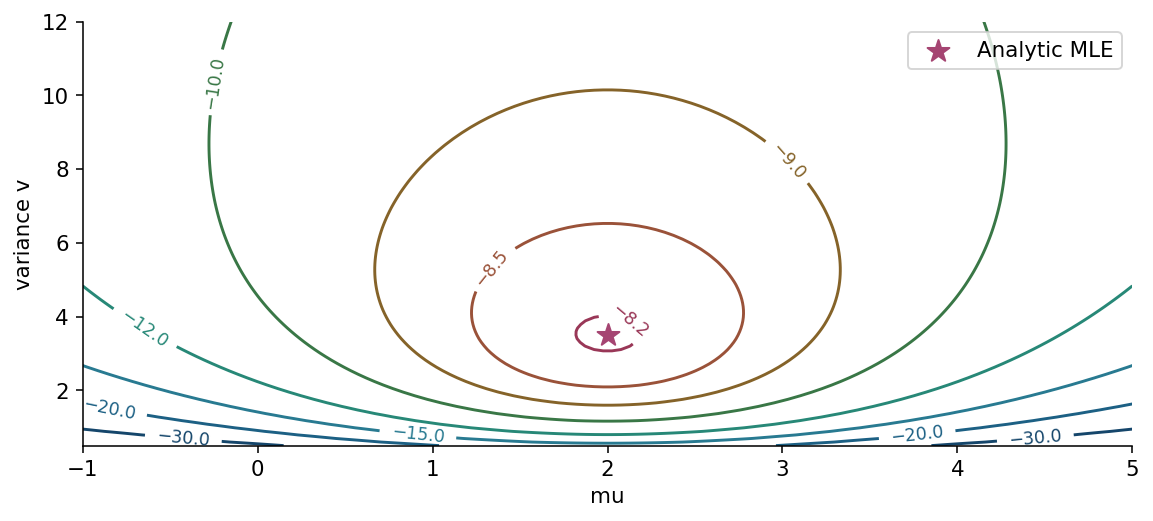

In [6]:
fit=e.gaussian_fit(x)
print(fit)
print("Residuals:",x-fit["mean"],"squares:",(x-fit["mean"])**2)
print("Derivatives at fitted pair:",e.gaussian_derivatives(x,2,3.5))
print("np.var ddof=0 / ddof=1:",np.var(x,ddof=0),np.var(x,ddof=1))
mu=np.linspace(-1,5,120); v=np.linspace(.5,12,120)
M,V=np.meshgrid(mu,v)
Z=-2*np.log(2*np.pi*V)-(14+4*(M-2)**2)/(2*V)
fig,ax=plt.subplots(figsize=(8.5,4))
curves=ax.contour(M,V,Z,levels=[-30,-20,-15,-12,-10,-9,-8.5,-8.2],colors=["#15466b","#1c6084","#287a91","#278877","#397746","#856329","#9a5239","#993757"])
ax.clabel(curves,fontsize=9);ax.scatter([2],[3.5],marker="*",s=140,color="#a54572",label="Analytic MLE")
ax.set(xlabel="mu",ylabel="variance v");ax.legend();show(fig)

### 6. 一维搜索核验联合推导
先由解析结果固定均值，再在z=logv中做黄金分割。log方差方向在S>0时严格凹，给了搜索所需的单峰保证；算法不会为任意黑箱目标证明全局最大。

In [7]:
solution=e.golden_maximize(lambda z:e.gaussian_loglik(x,fit["mean"],math.exp(z)),-5,5)
print(solution)
numeric_variance=math.exp(solution["x"])
e.require(solution["converged"],"Numerical search did not converge")
e.require(math.isclose(numeric_variance,3.5,rel_tol=1e-6,abs_tol=1e-6),"Numeric and analytic MLE disagree")
print("Numerical variance:",numeric_variance,"analytic:",3.5)
mu0,v0=1.8,4.1
analytic=e.gaussian_derivatives(x,mu0,v0)
for h in [1e-3,1e-4,1e-5]:
    dmu=(e.gaussian_loglik(x,mu0+h,v0)-e.gaussian_loglik(x,mu0-h,v0))/(2*h)
    dv=(e.gaussian_loglik(x,mu0,v0+h)-e.gaussian_loglik(x,mu0,v0-h))/(2*h)
    print("h",h,"finite difference",(dmu,dv),"analytic",analytic)

{'x': 1.2527629987256952, 'value': -8.181280069809427, 'bracket': [1.2527629982605772, 1.2527629991908134], 'iterations': 49, 'converged': True}
Numerical variance: 3.500000105806147 analytic: 3.5
h 0.001 finite difference (0.19512195121951237, -0.0666269923508267) analytic (0.19512195121951223, -0.06662700773349195)
h 0.0001 finite difference (0.1951219512186242, -0.06662700757331663) analytic (0.19512195121951223, -0.06662700773349195)
h 1e-05 finite difference (0.19512195121862416, -0.06662700782200659) analytic (0.19512195121951223, -0.06662700773349195)


### 7. 故意漏掉归一化项，并检查全同值失败
错误目标不是同一模型的另一个实现。全同值时None表示无有限MLE，不能把描述均值与零方差拼成成功的Gaussian密度拟合。

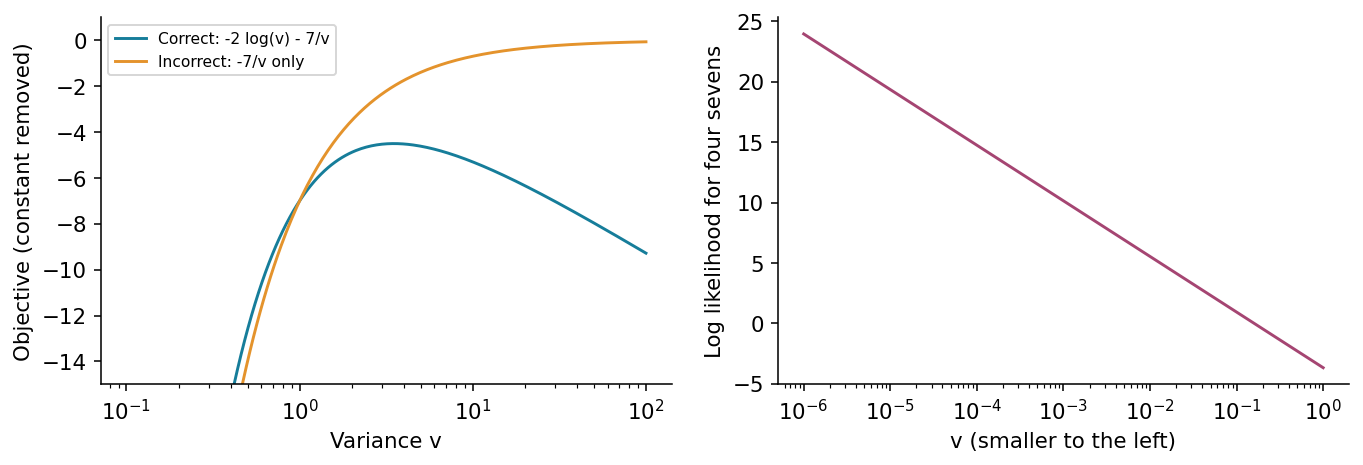

Four identical: {'n': 4, 'mean': 7.0, 'sse': 0.0, 'variance_mle': None, 'variance_unbiased': 0.0, 'status': 'no_finite_mle_unbounded_likelihood'}
Single observation: {'n': 1, 'mean': 7.0, 'sse': 0.0, 'variance_mle': None, 'variance_unbiased': None, 'status': 'no_finite_mle_unbounded_likelihood'}


In [8]:
vs=np.geomspace(.1,100,300)
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(vs,-2*np.log(vs)-7/vs,color="#167d9a",label="Correct: -2 log(v) - 7/v")
axes[0].plot(vs,-7/vs,color="#e4932c",label="Incorrect: -7/v only")
axes[0].set(xscale="log",xlabel="Variance v",ylabel="Objective (constant removed)",ylim=(-15,1))
axes[0].legend(fontsize=8)
vs2=np.geomspace(1e-6,1,200)
axes[1].plot(vs2,[e.gaussian_loglik([7]*4,7,float(v)) for v in vs2],color="#a54572")
axes[1].set(xscale="log",xlabel="v (smaller to the left)",ylabel="Log likelihood for four sevens")
show(fig)
print("Four identical:",e.gaussian_fit([7,7,7,7]))
print("Single observation:",e.gaussian_fit([7]))

### 8. 只改一个观测
样本(0,1,2,t)的两项解析式同时与通用拟合函数比较。没有删除极端值，也没有把这种机制实验叫现实异常检测性能。

Baseline: {'n': 4, 'mean': 2.0, 'sse': 14.0, 'variance_mle': 3.5, 'variance_unbiased': 4.666666666666667, 'status': 'finite_unique_mle'}
Replace final observation: {'n': 4, 'mean': 6.0, 'sse': 302.0, 'variance_mle': 75.5, 'variance_unbiased': 100.66666666666667, 'status': 'finite_unique_mle'}


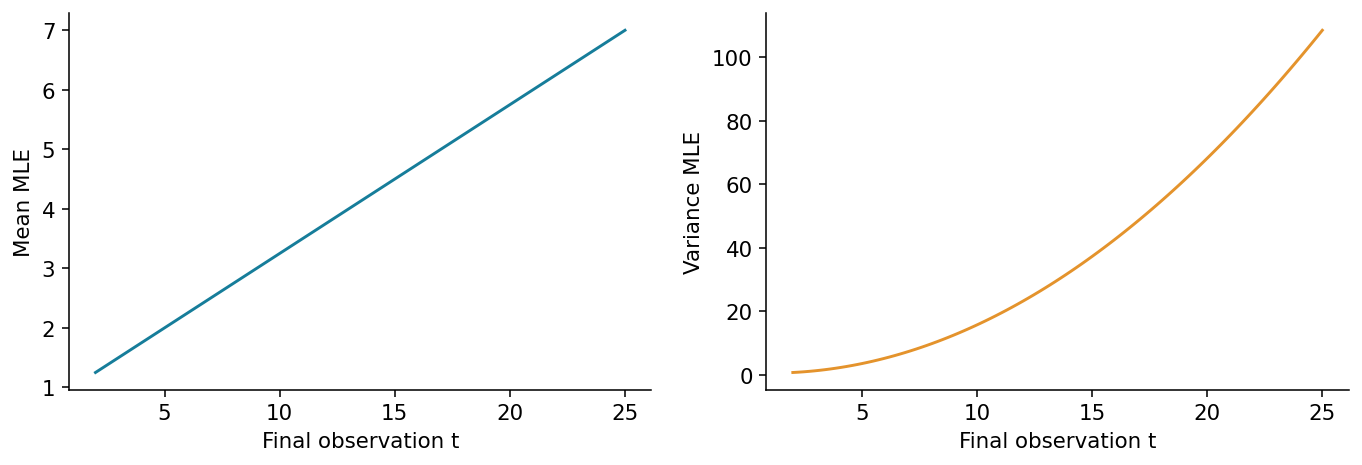

In [9]:
print("Baseline:",e.gaussian_fit([0,1,2,5]))
print("Replace final observation:",e.gaussian_fit([0,1,2,21]))
ts=np.linspace(2,25,100);means=[];variances=[]
for t in ts:
    result=e.gaussian_fit([0,1,2,float(t)])
    e.require(math.isclose(result["mean"],(3+t)/4,rel_tol=1e-12),"Mean formula mismatch")
    e.require(math.isclose(result["variance_mle"],(3*t*t-6*t+11)/16,rel_tol=1e-12),"Variance formula mismatch")
    means.append(result["mean"]);variances.append(result["variance_mle"])
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(ts,means,color="#167d9a");axes[0].set(xlabel="Final observation t",ylabel="Mean MLE")
axes[1].plot(ts,variances,color="#e4932c");axes[1].set(xlabel="Final observation t",ylabel="Variance MLE")
show(fig)

### 9. 直接相加log，避免先乘后丢失
下面的直接乘积故意展示浮点下溢。它不参与正常估计流程，精确数学结果仍严格大于0。log1p保留小量。

In [10]:
n=2000
naive=(.5)**n
stable=e.bernoulli_loglik([0]*n,.5)
print("Float product:",naive,"exact value is 2^(-2000), positive")
print("Stable log likelihood:",stable,"expected",-2000*math.log(2))
p=1e-20
print("log(1-p):",math.log(1-p),"log1p(-p):",math.log1p(-p))
print("Normal peak with variance .01:",1/math.sqrt(2*math.pi*.01))

Float product: 0.0 exact value is 2^(-2000), positive
Stable log likelihood: -1386.2943611198905 expected -1386.2943611198905
log(1-p): 0.0 log1p(-p): -1e-20
Normal peak with variance .01: 3.989422804014327


### 10. 每批n与重复次数R分开
一行原始矩阵是一批完整实验，参数估计沿列方向进行。现在的曲线比较估计量的重复期望，不是把所有4000n个观测当成一批拟合。理论期望不依赖种子；有限模拟平均会波动。

{'n': 4, 'repetitions': 4000, 'mean_p_mle': 0.3744375, 'mean_mu_mle': 2.012257630848643, 'mean_variance_mle': 2.644831359724969, 'mean_variance_unbiased': 3.5264418129666257, 'theory_mean_variance_mle': 2.625, 'theory_mean_variance_unbiased': 3.5}
{'n': 16, 'repetitions': 4000, 'mean_p_mle': 0.3736875, 'mean_mu_mle': 1.9915373234360267, 'mean_variance_mle': 3.296567229198508, 'mean_variance_unbiased': 3.516338377811742, 'theory_mean_variance_mle': 3.28125, 'theory_mean_variance_unbiased': 3.5}
{'n': 64, 'repetitions': 4000, 'mean_p_mle': 0.37465234375, 'mean_mu_mle': 2.0000092812462604, 'mean_variance_mle': 3.435376030965389, 'mean_variance_unbiased': 3.4899058092346804, 'theory_mean_variance_mle': 3.4453125, 'theory_mean_variance_unbiased': 3.5}


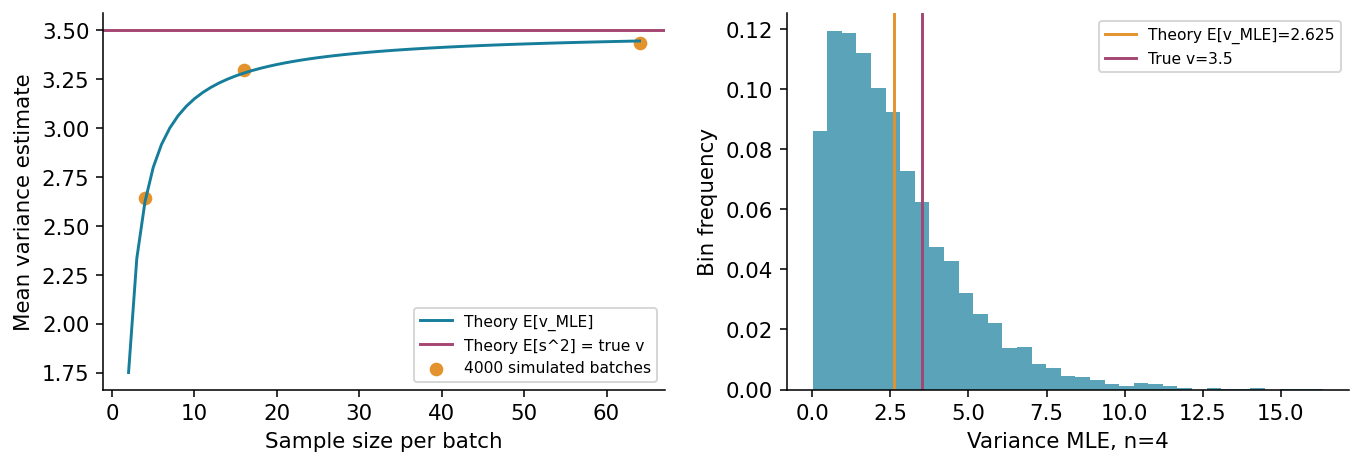

In [11]:
repeated=e.repeat_sampling(spec)
for row in repeated["summaries"]:print(row)
ns=np.arange(2,65)
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(ns,(ns-1)/ns*3.5,color="#167d9a",label="Theory E[v_MLE]")
axes[0].axhline(3.5,color="#a54572",label="Theory E[s^2] = true v")
for row in repeated["summaries"]:
    axes[0].scatter(row["n"],row["mean_variance_mle"],color="#e4932c")
axes[0].scatter([],[],color="#e4932c",label="4000 simulated batches")
axes[0].set(xlabel="Sample size per batch",ylabel="Mean variance estimate");axes[0].legend(fontsize=8)
vals=repeated["samples"][4]["variance_mle"]
axes[1].hist(vals,bins=35,weights=np.ones(len(vals))/len(vals),color="#167d9a",alpha=.7)
axes[1].axvline(2.625,color="#e4932c",label="Theory E[v_MLE]=2.625")
axes[1].axvline(3.5,color="#a54572",label="True v=3.5")
axes[1].set(xlabel="Variance MLE, n=4",ylabel="Bin frequency");axes[1].legend(fontsize=8)
show(fig)

## Checks
### 11. 错误要显式失败
普通数值API拒绝bool、文本、complex、object dtype与非有限值；CSV解析文本遵循单独的严格语法。不能删掉坏数据后仍称自己拟合了原样本。

In [12]:
print("Reference checks:",e.reference_checks())
print("Boundary checks:",e.boundary_checks())
for label,call in [("mixed bool",lambda:e.gaussian_fit([0,True])),("text",lambda:e.bernoulli_mle([0,"1"])),("NaN",lambda:e.gaussian_fit([0,float("nan")])),("object",lambda:e.gaussian_fit(np.array([0,1],dtype=object))),("zero variance",lambda:e.gaussian_loglik([0],0,0))]:
    try:call()
    except ValueError as error:print(label,"->",str(error))
    else:raise ValueError("Invalid input accepted")

Reference checks: {'passed': 474}
Boundary checks: {'rejected': 23, 'accepted_edge_cases': 4}
mixed bool -> data: real numeric scalar required
text -> data: real numeric scalar required
NaN -> data: finite value required
object -> data: bool, text, complex and object dtypes rejected
zero variance -> variance: outside documented range


### 12. 坏配置必须在随机流或目标回调之前失败
哨兵函数若被触碰就抛RuntimeError；正确行为应先收到输入检查的ValueError。此处不修改任何结果文件。

In [13]:
from unittest.mock import patch
bad=dict(spec);bad["sizes"]=[4,True]
with patch.object(np.random,"PCG64",side_effect=RuntimeError("RNG touched too early")):
    try:e.repeat_sampling(bad)
    except ValueError as error:print("Pre-RNG rejection:",str(error))
    else:raise ValueError("Expected invalid specification failure")
calls=[]
def objective(z):
    calls.append(z);return -(z-1)**2
try:e.golden_maximize(objective,0,2,max_iterations=True)
except ValueError as error:print("Pre-callback rejection:",str(error))
else:raise ValueError("Expected invalid iteration failure")
e.require(calls==[],"Callback was invoked before complete argument validation")
print("Callback invocation count:",len(calls))

Pre-RNG rejection: sample size: integer required
Pre-callback rejection: max_iterations: integer required
Callback invocation count: 0


## Next Steps
完成正文18题，再另存输入做一个单因素变化实验。先写参数空间与支持集，再写预期方向，最后核对输出；不得把有限模拟当成理论证明。完整运行说明和数值范围见README.md与lab.pdf。

本Notebook从新的Python进程中的真实InProcessKernel逐格执行并保留图像。浏览器Jupyter界面、常规socket传输、读者Anaconda安装与跨NumPy版本逐位复现未测试。数学模型v>0与实现的有限范围是不同层次；任何超范围拒绝不表示数学上的MLE不存在。